# Phase 2a-3. TME composition analysis

이 notebook의 목적은 TAM subtype별 세포 수/비율을 sample 단위로 계산하여, 종양 미세환경(TME)에서 C1QC+ TAM과 SPP1+ TAM의 구성 비율이 샘플마다 어떻게 다른지 확인하는 것이다

DEG가 gene-level 분석이라면, TME composition은 cell-level 분석이다

- DEG: 어떤 gene이 subtype을 구분하는가?
- TME composition: 어떤 cell subtype이 sample마다 얼마나 존재하는가?

In [4]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from utils.paths import *

mac = sc.read_h5ad(MAC_PH2_H5AD)
print(mac)
print(mac.obs['tam_subtype'].value_counts())
print((mac.obs['tam_subtype'].value_counts(normalize=True) * 100).round(2))


AnnData object with n_obs × n_vars = 8144 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts', 'sample', 'leiden', 'cell_type', 'tam_subtype'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'deg_tam', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'tam_subtype_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
tam_subtype
Unknown      4526
SPP1+ TAM    2440
C1QC+ TAM    1178
Name: count, dtyp

## 1. 샘플별 TAM subtype composition 계산

전체 macrophage subset에서 subtype 비율을 보는 것도 중요하지만, 논문/임상적 질문에서는 sample 또는 patient 단위의 차이가 더 중요하다.

예:
- 어떤 sample은 C1QC+ TAM 비율이 높을 수 있음
- 어떤 sample은 SPP1+ TAM 비율이 높을 수 있음
- 어떤 sample은 macrophage subtype annotation이 거의 Unknown으로 남을 수 있음

이 비율은 이후 Phase 3에서 치료 반응군 vs 비반응군 비교로 확장될 수 있다.

In [5]:
required_cols = ['sample', 'tam_subtype']
missing_cols = [c for c in required_cols if c not in mac.obs.columns]
print('missing required columns:', missing_cols)

# composition - 암종별 * 서브타입별 세포 수 원본 테이블
composition = (
    mac.obs
    .groupby(['sample', 'tam_subtype'], observed=False)
    .size()
    .unstack(fill_value=0)
)

#composition_pct - composition 테이블을 백분율(비율)로 변환한 테이블
composition_pct = composition.div(composition.sum(axis=1), axis=0) * 100

display(composition.style.set_caption('TAM Subtype Cell Count by Cancer Type'))
display(composition_pct.round(1).style
        .set_caption('TAM Subtype Composition by Cancer Type')
        .format('{:.1f}%'))

missing required columns: []


tam_subtype,C1QC+ TAM,SPP1+ TAM,Unknown
sample,,,
0,100,234,325
1,103,245,372
2,46,104,133
3,57,132,174
4,0,17,194
5,0,24,275
6,0,34,275
7,2,8,18
8,1,8,15


tam_subtype,C1QC+ TAM,SPP1+ TAM,Unknown
sample,,,
0,15.2%,35.5%,49.3%
1,14.3%,34.0%,51.7%
2,16.3%,36.7%,47.0%
3,15.7%,36.4%,47.9%
4,0.0%,8.1%,91.9%
5,0.0%,8.0%,92.0%
6,0.0%,11.0%,89.0%
7,7.1%,28.6%,64.3%
8,4.2%,33.3%,62.5%


## 2. Stacked bar plot

Sample별 C1QC+ TAM / SPP1+ TAM / Unknown 비율을 stacked bar plot으로 확인한다.

해석 포인트:
- C1QC+ TAM과 SPP1+ TAM이 함께 관찰되는 sample이 있는지
- Unknown 비율이 과도하게 높은 sample이 있는지
- sample별 TAM infiltration pattern이 균일한지 또는 heterogeneous한지

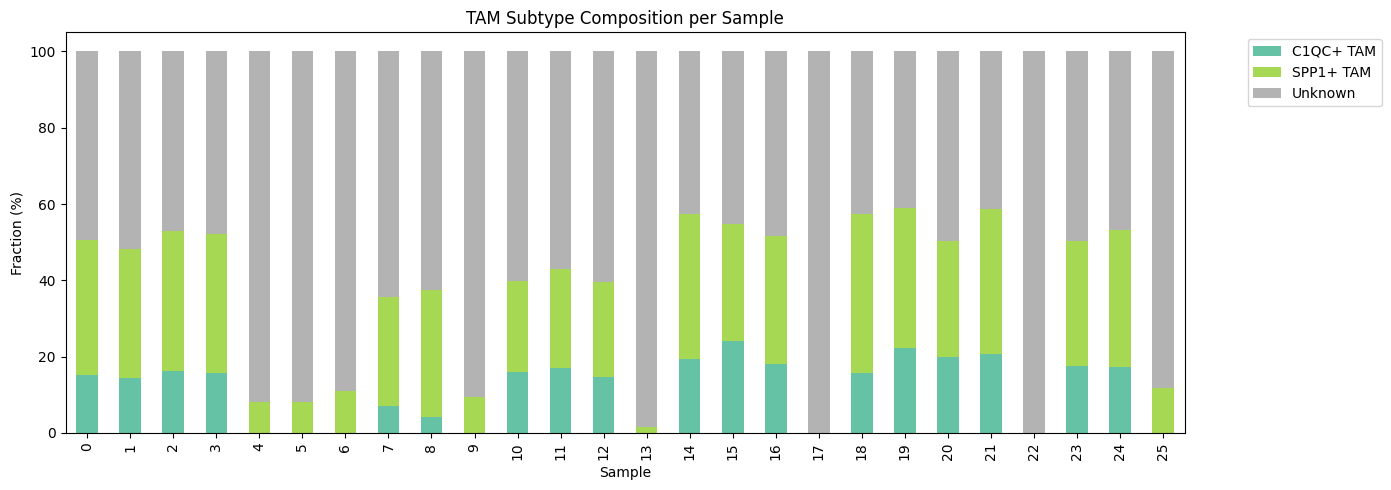

In [6]:
composition_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 5),
    colormap='Set2'
)
plt.title('TAM Subtype Composition per Sample')
plt.ylabel('Fraction (%)')
plt.xlabel('Sample')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


## 3. TAM-rich / TAM-low sample 분류

Unknown 비율이 너무 높으면 해당 sample에서는 C1QC+ TAM / SPP1+ TAM signal이 약하거나, annotation 기준으로 subtype 분리가 충분히 되지 않은 것으로 볼 수 있다.

여기서는 간단히 Unknown 비율 90%를 기준으로 TAM-rich / TAM-low-like sample을 구분해본다.

In [7]:
unknown_col = 'Unknown'
if unknown_col in composition_pct.columns:
    tam_low_samples = composition_pct[composition_pct[unknown_col] >= 90].index.tolist()
    tam_rich_samples = composition_pct[composition_pct[unknown_col] < 90].index.tolist()

    print('TAM-rich-like samples:', tam_rich_samples)
    print('TAM-low-like / Unknown-dominant samples:', tam_low_samples)

    summary = pd.DataFrame({
        'sample_group': ['TAM-rich-like', 'TAM-low-like'],
        'n_samples': [len(tam_rich_samples), len(tam_low_samples)]
    })
    display(summary)
else:
    print('Unknown column not found in composition table')

TAM-rich-like samples: ['0', '1', '2', '3', '6', '7', '8', '10', '11', '12', '14', '15', '16', '18', '19', '20', '21', '23', '24', '25']
TAM-low-like / Unknown-dominant samples: ['4', '5', '9', '13', '17', '22']


,sample_group,n_samples
0,TAM-rich-like,20
1,TAM-low-like,6


## 4. Interpretation note

현재 결과는 sample마다 TAM subtype composition이 다르다는 점을 보여준다.

다만 이 단계만으로 예후나 치료 반응을 직접 말할 수는 없다. 예후/치료 반응과 연결하려면 sample별 임상 정보 또는 treatment response label이 필요하다.

따라서 Phase 2a의 의미는 다음과 같다.

1. C1QC+ TAM / SPP1+ TAM subtype을 GSE127465에서 재현
2. DEG overlap으로 논문 marker signature 재현 확인
3. sample-level TAM composition 분석으로 Phase 3의 치료 반응 비교를 위한 기반 생성

In [8]:
mac.write(MAC_TME_H5AD)
print(f'저장 완료: {MAC_TME_H5AD}')

저장 완료: dataset\GSE127465_mac_phase2a_tme.h5ad


# Phase 2b. 다암종 확장 및 독립 검증

목표: pan-cancer 패턴 독립 검증

`다암종으로 확장하기에 앞서 추가해서 받아야 할 데이터`
GSE154763 — Set 1, 8개 암종 한번에 있는 데이터 셋, 이미 골수계 세포만 뽑혀있는 데이터라 전처리 부담 down
GSE131907 — LUAD, 내가 전처리 한 GSE127465랑 같은 폐암이라 직접 비교 가능

https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE154763
- LYM_metadata.csv.gz (19.3 Kb)
- LYM_normalized_expression.csv.gz (2.5 Mb)

https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE131907
- 미정
- 미정

파일 구조 확인
- 이미 normalized 된 데이터가 있어 QC 및 정규화 진행하지 않아도 됨
- 하지만 raw data가 없어서 use_raw=True는 사용 불가능

다운 받은 LYM 파일은 csv 형식이기 때문에 h5ad파일로 파싱 해줘야 한다
그 전에 원본 csv 파일을 까서 메타데이터 및 컬럼을 확인해줘야 한다 -> 샘플 정보 확인 차

### LYM_META 확인결과
Major Cluster: 이미 cell type annotation 완료 되어있음 -> M06_Macro_ISG25같은 형식
cancer: LYM(림프종)
patient: 환자ID
tissue: T(tumor)
UMAP1/2

=> 클러스터에 이미 Macrophage annotation이 되어있음

In [9]:
import pandas as pd

meta = pd.read_csv(LYM_META)
print(meta.shape)
print(meta.columns.tolist())
print(meta.head())

(615, 14)
['index', 'batch', 'patient', 'tissue', 'percent_hsp', 'percent_mito', 'n_genes', 'n_counts', 'MajorCluster', 'source', 'tech', 'cancer', 'UMAP1', 'UMAP2']
                 index  batch    patient tissue  percent_hsp  percent_mito  \
0  AACACGTGTTTGGGCC-15     15  P20181123      T     0.006040           0.0   
1  AACCGCGAGTTCGCAT-15     15  P20181123      T     0.003356           0.0   
2  AACTGGTAGCCACTAT-15     15  P20181123      T     0.000368           0.0   
3  AAGGCAGTCGTCGTTC-15     15  P20181123      T     0.004203           0.0   
4  AAGGTTCAGATAGGAG-15     15  P20181123      T     0.016225           0.0   

   n_genes  n_counts     MajorCluster    source  tech cancer     UMAP1  \
0     4789   29802.0  M02_cDC1_CLEC9A  ZhangLab  10X5    LYM  0.572999   
1     1641    5065.0  M06_Macro_ISG15  ZhangLab  10X5    LYM  5.801088   
2      922    2716.0  M06_Macro_ISG15  ZhangLab  10X5    LYM  4.989789   
3     1511    4759.0  M06_Macro_ISG15  ZhangLab  10X5    LYM  4.95462

LYM에서는 ISG1+ 가 압도적으로 많음
GSE127465 폐암데이터에서는 ISG15+ 클러스터가 안보였던 것과는 대조적인 모습이다
M07_Macro_C1QC가 29개 밖에 없다 -> LYM에서 조직 상주 대식세포가 적음

In [10]:
print(meta['MajorCluster'].value_counts())
print(meta['cancer'].value_counts())

MajorCluster
M06_Macro_ISG15    264
M04_Mono_CD14      141
M05_Mono_CD16      121
M07_Macro_C1QC      29
M03_cDC2_CD1C       26
M01_pDC_LILRA4      22
M02_cDC1_CLEC9A     12
Name: count, dtype: int64
cancer
LYM    615
Name: count, dtype: int64


expression matrix 불러와서 AnnData로 merge 작업 진행

shape 로그 찍어보니까 현재 `LYM_normalized_expression` data는 cell이 row, gene이 column으로 정상적으로 데이터가 들어가있기에 .T로 전치 해줄 필요가 없음
(5, 11283) -> `행x열`
['AACACGTGTTTGGGCC-15', 'AACCGCGAGTTCGCAT-15', 'AACTGGTAGCCACTAT-15'] -> `cell barcord -15(batch/샘플번호)`
['FO538757.2', 'LINC00115', 'NOC2L'] -> `genes`

sparse 행렬 + float32 다운캐스팅으로 메모리 절약
- 기본값인 float64 대신 float32 사용 → 메모리 절반으로 감소
- csr_matrix로 희소행렬 변환 → 0이 많은 scRNA-seq 데이터에 효율적

In [11]:
expr = pd.read_csv(LYM_NM, index_col=0, nrows=5)
print(expr.shape)
print(expr.index[:3].tolist())
print(expr.columns[:3].tolist())

(5, 11283)
['AACACGTGTTTGGGCC-15', 'AACCGCGAGTTCGCAT-15', 'AACTGGTAGCCACTAT-15']
['FO538757.2', 'LINC00115', 'NOC2L']


In [12]:
import anndata as ad
import scipy.sparse as sp

# 전체 로딩 후 전치
expr = pd.read_csv(LYM_NM, index_col=0)

print(expr.shape)  # (615, 11283) 나와야 함

# AnnData 생성
adata_lym = ad.AnnData(sp.csr_matrix(expr.values.astype('float32')))
adata_lym.obs_names = expr.index.tolist()
adata_lym.var_names = expr.columns.tolist()

# 메타데이터 붙이기
adata_lym.obs = meta.set_index('index')

print(adata_lym)

adata_lym.uns['normalized'] = True
adata_lym.uns['source'] = 'GSE154763'
adata_lym.uns['cancer'] = 'LYM'

adata_lym.write_h5ad(LYM_H5AD)
print(f"Saved -> {LYM_H5AD}")

(615, 11283)
AnnData object with n_obs × n_vars = 615 × 11283
    obs: 'batch', 'patient', 'tissue', 'percent_hsp', 'percent_mito', 'n_genes', 'n_counts', 'MajorCluster', 'source', 'tech', 'cancer', 'UMAP1', 'UMAP2'
Saved -> dataset\phase2b\GSE154763_LYM.h5ad


같은 작업을 8개의 암종 모두 진행해야해서 루프문 짬

In [13]:
from tqdm import tqdm

cancers = ['ESCA', 'KIDNEY', 'LYM', 'MYE', 'OV-FTC', 'PAAD', 'THCA', 'UCEC']

adata_list = []

for cancer in tqdm(cancers, desc="Loading"):
    expr_path = CSV_DIR / f'GSE154763_{cancer}_normalized_expression.csv.gz'
    meta_path = CSV_DIR / f'GSE154763_{cancer}_metadata.csv.gz'
    
    expr = pd.read_csv(expr_path, index_col=0)
    meta = pd.read_csv(meta_path)
    
    adata = ad.AnnData(sp.csr_matrix(expr.values.astype('float32')))
    adata.obs_names = expr.index.tolist()
    adata.var_names = expr.columns.tolist()
    adata.obs = meta.set_index('index')
    
    adata_list.append(adata)
    del expr

# all merge
adata_all = sc.concat(adata_list, join='outer', index_unique='-')
print(adata_all)

adata_all.write_h5ad(ALL_H5AD)
print('저장 완료')

Loading: 100%|██████████| 8/8 [04:04<00:00, 30.56s/it]


AnnData object with n_obs × n_vars = 65698 × 18486
    obs: 'percent_mito', 'n_counts', 'percent_hsp', 'barcode', 'batch', 'library_id', 'cancer', 'patient', 'tissue', 'n_genes', 'MajorCluster', 'source', 'tech', 'UMAP1', 'UMAP2'
저장 완료


In [14]:
print(adata_all.obs['cancer'].value_counts())
print(adata_all.obs['MajorCluster'].value_counts())

cancer
KIDNEY    28930
UCEC       8808
ESCA       7673
MYE        7619
THCA       5312
OV-FTC     3888
PAAD       2853
LYM         615
Name: count, dtype: int64
MajorCluster
M07_Mono_CD16        11093
M06_Mono_CD14         9058
M04_cDC2_CD1C         7702
M09_Macro_C1QC        3953
M08_Macro_NLRP3       3903
M01_Mast_KIT          3868
M11_Macro_C1QC        2401
M09_Macro_IL1B        2363
M05_Mono_CD14         2321
M10_Macro_GPNMB       2264
M12_Macro_LYVE1       2202
M08_Macro_SPP1        1709
M06_Mono_CD14CD16     1608
M10_Macro_C1QC        1544
M08_Macro_FN1         1319
M11_Macro_LYVE1       1217
M13_Macro_INHBA       1100
M10_Macro_SPP1        1072
M09_Macro_INHBA        947
M05_cDC3_LAMP3         734
M02_pDC_LILRA4         675
M03_cDC1_CLEC9A        619
M09_Macro_SPP1         498
M03_cDC2_CD1C          340
M09_Macro_ISG15        318
M06_Macro_ISG15        264
M11_Macro_ISG15        144
M04_Mono_CD14          141
M05_Mono_CD16          121
M01_pDC_LILRA4         111
M02_cDC1_CLEC9A 

In [15]:
# Macrophage만 추출
import scanpy as sc

adata_all = sc.read_h5ad(ALL_H5AD)
mac_clusters = adata_all.obs['MajorCluster'].value_counts()
mac_only = mac_clusters[mac_clusters.index.str.contains('Macro')]
print(mac_only)

MajorCluster
M09_Macro_C1QC     3953
M08_Macro_NLRP3    3903
M11_Macro_C1QC     2401
M09_Macro_IL1B     2363
M10_Macro_GPNMB    2264
M12_Macro_LYVE1    2202
M08_Macro_SPP1     1709
M10_Macro_C1QC     1544
M08_Macro_FN1      1319
M11_Macro_LYVE1    1217
M13_Macro_INHBA    1100
M10_Macro_SPP1     1072
M09_Macro_INHBA     947
M09_Macro_SPP1      498
M09_Macro_ISG15     318
M06_Macro_ISG15     264
M11_Macro_ISG15     144
M07_Macro_C1QC       29
Name: count, dtype: int64


In [16]:
def map_tam_subtype(cluster):
    if 'C1QC' in cluster:
        return 'C1QC+ TAM'
    elif 'SPP1' in cluster:
        return 'SPP1+ TAM'
    elif 'ISG15' in cluster:
        return 'ISG15+ TAM'
    else:
        return 'Other Macrophage'
    
adata_mac = adata_all[adata_all.obs['MajorCluster'].str.contains('Macro')].copy()
adata_mac.obs['tam_subtype'] = adata_mac.obs['MajorCluster'].apply(map_tam_subtype)

print(adata_mac.obs['tam_subtype'].value_counts())

tam_subtype
Other Macrophage    15315
C1QC+ TAM            7927
SPP1+ TAM            3279
ISG15+ TAM            726
Name: count, dtype: int64


### observed = True 옵션
groupbe 할 때 실제로 데이터에 존재하는 조합만 집계하겠다는 것
예를들어 cancer가 KIDNEY, LYM이고 tam_subtype이 C1QC+, SPP1+, ISG15, Other이라면 이론적으로 가능한 조합은 2*4=8개다
근데 LYM에 ISG15+가 없을 수도 있잖음
그때 observed = False (default)라면
```LYM / ISG15+ TAM -> 0 # 없어도 행을 만들어 줌```
근데 만약 observed = True 라면
```LYM / ISG15+ TAM -> 아예 행 자체가 없음```

scRNA-seq에서는 observed = True가 맞는 이유임
없는 조합을 0으로 채우면 fill_value=0이 처리해주니까 observed = True로 실제 있는거만 집계하고 unstack할 때 빈칸은 0으로 채울 수 있음

In [17]:
# 각 암종 별로 C1QC+ TAM, SPP1+ TAM, ISG15+ 비율이 어떻게 다른지 확인

import pandas as pd
import matplotlib.pyplot as plt

composition = (
    adata_mac.obs
    .groupby(['cancer', 'tam_subtype'], observed=True)
    .size()
    .unstack(fill_value=0)
)

composition_pct = composition.div(composition.sum(axis=1), axis=0) * 100
print(composition_pct.round(1))

tam_subtype  C1QC+ TAM  ISG15+ TAM  Other Macrophage  SPP1+ TAM
cancer                                                         
ESCA              22.8         0.0              77.2        0.0
KIDNEY            17.5         0.0              82.5        0.0
LYM                9.9        90.1               0.0        0.0
MYE               86.9         0.0              13.1        0.0
OV-FTC            58.7         0.0               0.0       41.3
PAAD              74.2         0.0               0.0       25.8
THCA              13.3         4.3              67.4       15.0
UCEC              20.6         7.6              46.2       25.6


### 결과 분석
암종 별로 패턴이 완전히 다르다

C1QC+ TAM 우세 (조직 상주 대식세포가 많음)
- MYE 86.9%, PAAD 74.2%, OV-FTC 58.7% -> 예후 좋은 계열이 지배적
ISG15+ TAM
- LYM 90.1% - 압도적. 림프종 특이적 패턴 확인
- THCA 4.3%, UCEC 7.6% - 소량 존재
SPP1+ TAM이 0인 암종들
- ESCA, KIDMEY, LYM, MYE - 이 암종들은 SPP1+ 계열이 Other Macrophage로 분류됨

> 논문의 주장인 C1QC+ vs SPP1+의 이분법이 암종마다 다르게 나타나는 것
이것이 pan-cancer 분석의 핵심

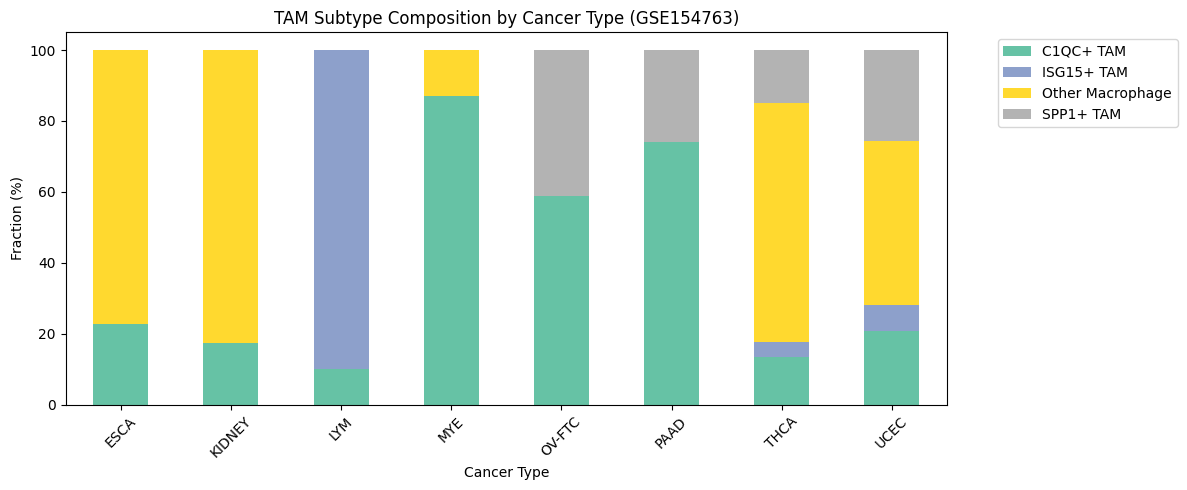

In [18]:
composition_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 5),
    colormap='Set2'
)
plt.title('TAM Subtype Composition by Cancer Type (GSE154763)')
plt.ylabel('Fraction (%)')
plt.xlabel('Cancer Type')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### 그래프 분석
- LYM: ISG15+ 압도적 -> 다른 암종과는 완전히 다른 패턴
- MYE, PAAD: C1QC+ 지배적
- ESCA, KIDNEY: Other Macrophage가 많음
- OC-FTC: C1QC+ SPP1+ 양쪽 다 있음

> Phase2a에서 "ISG15+가 폐암 단일 데이터에서 보이지 않았다"는 한계를 다암종으로 확장하여 검증완료

In [ ]:
# 저장
adata_mac.write_h5ad(ALL_MAC_H5AD)
print(f'저장 완료: {ALL_MAC_H5AD}')

저장 완료: dataset\GSE154763_all_mac.h5ad
